# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import foxes
import foxes.variables as FV
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error,mean_squared_error
import customFunctions as fct
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn import neighbors, linear_model, gaussian_process
import os
import foxes.input.farm_layout as layout
import xarray as xr

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628','f781bf','999999'])
plt.rcParams['figure.figsize'] = [26.67/2, 13.25/2]
plt.rcParams['figure.dpi'] = 600

In [ ]:
# Read in the wind data from the provided .csv files
data_ERA5 = fct.read_ts_csv(f'reanalysis.csv')
data_LIDAR = fct.read_ts_csv(f'measurements/lidar.csv')

# Resample the data to 1h intervals
data_ERA5 = data_ERA5.resample('h', on='Time').mean()
data_ERA5['u100'], data_ERA5['v100'] = fct.wind_components(data_ERA5.iloc[:, 0], data_ERA5.iloc[:, 1])

data_LIDAR = data_LIDAR.resample('h', on='Time').mean()
data_LIDAR['u99.2'], data_LIDAR['v99.2'] = fct.wind_components(data_LIDAR.iloc[:, 0], data_LIDAR.iloc[:, 1])

# create a merged dataframe containing the ERA5 and the LIDAR data
wind_data = pd.merge(data_LIDAR, data_ERA5, how='right', on='Time')

# Ensure that the datetime format is used for the datetime index
wind_data.index = pd.to_datetime(wind_data.index)

# Feature Engineering
wind_data['Mon']      = wind_data.index.strftime('%m')
wind_data['Hour']     = wind_data.index.strftime('%H')
wind_data["TI"] = 0.10  # constant turbulence

# Long-Term Wind Correction

In [ ]:
import sklearn.gaussian_process

# Define parameter grids for all the correction models that are to be used
param_grid_KNeighbors = {
              "n_neighbors"       : [2, 5, 12, 30],
              "leaf_size"         : [1, 2, 3, 15,30],
              "p"                 : [1, 2],
              "weights"           : ['uniform', 'distance'],
              "metric"            : ['euclidean', 'manhattan', 'minkowski'] 
             }

param_grid_RadiusNeighborsRegressor = {
              "radius"            : np.arange(0.2, 2, .2),
              "leaf_size"         : np.arange(1, 10, 1),
              "p"                 : [1, 2],
              "weights"           : ['uniform', 'distance'],
              "metric"            : ['euclidean', 'manhattan', 'minkowski'] 
             }

param_grid_LinReg = {
            "fit_intercept"     : [False, True],
            "copy_X"            : [False, True]
}

# Define kernels for the gaussian process:
ker_rbf = sklearn.gaussian_process.kernels.ConstantKernel(1.0, constant_value_bounds="fixed") * sklearn.gaussian_process.kernels.RBF(1.0, length_scale_bounds="fixed")

ker_rq = sklearn.gaussian_process.kernels.ConstantKernel(1.0, constant_value_bounds="fixed") * sklearn.gaussian_process.kernels.RationalQuadratic(alpha=0.1, length_scale=1)

ker_expsine = sklearn.gaussian_process.kernels.ConstantKernel(1.0, constant_value_bounds="fixed") * sklearn.gaussian_process.kernels.ExpSineSquared(1.0, 5.0, periodicity_bounds=(1e-2, 1e1))

kernel_list = [ker_rbf, ker_rq, ker_expsine]

param_grid_Gaussian = {
            "kernel"    : kernel_list, # ['ExpSineSquared', 'ConstantKernel', 'WhiteKernel']
            "alpha"     : np.arange(4, 10, 0.5) * 10 ** -10,
            "optimizer" : ['fmin_l_bfgs_b']
}

# Store all param grids in a list for later iteration
param_grids = [param_grid_LinReg, param_grid_KNeighbors, param_grid_Gaussian] # , param_grid_RadiusNeighborsRegressor

# define the classifiers that are to be used in the wind data correction
classifiers = [sklearn.linear_model.LinearRegression(), sklearn.neighbors.KNeighborsRegressor(), sklearn.gaussian_process.GaussianProcessRegressor()] # , sklearn.neighbors.RadiusNeighborsRegressor()

# Store classifier names in a list for later use as labels etc
classifier_names = ['LinReg', 'KNeighbors', 'GaussianProcess'] # , 'GaussianProcess'

In [ ]:
# preallocate empty lists for the u,v component predictions
u_predictions = []
v_predictions = []

# iterate through each classifier and grid and calculate the long term correction of the u,v-components of the wind
for (grid, classifier, i) in zip(param_grids, classifiers, range(len(param_grids))) :
    u_pred, meas_idx, _ = fct.correct_long_term_wind(wind_data[['u100','WS100','WD100','Mon','Hour']], wind_data['u99.2'], 
                                                   classifier=classifier, param_grid=grid)

    v_pred, _, _ = fct.correct_long_term_wind(wind_data[['v100','WS100','WD100','Mon','Hour']], wind_data['v99.2'], 
                                                   classifier=classifier, param_grid=grid)
    
    # append the current prediction to the predicted list
    u_predictions.append(u_pred)
    v_predictions.append(v_pred)
    del u_pred, v_pred
    
# store the meas_idx in an external file, such that this code cell does not need to be run more than once
np.savetxt('meas_idx.txt', meas_idx)

# preallocate empty lists for the wind speed and wind direction predictions  
WS_predictions = []
WD_predictions = []

# iterate through the list of u,v-component predictions and calculate the wind speed and direction from them
for (u, v)in zip(u_predictions, v_predictions):
    WS_pred, WD_pred = fct.wind_speed_dir(u, v)
    
    # append the wind speed and direction to the preallocated lists
    WS_predictions.append(WS_pred)
    WD_predictions.append(WD_pred)
    del WS_pred, WD_pred

# store the predictions in a dataframe with the columns WS_predictions, WS_predictions
df_predictions = pd.DataFrame(np.concat([np.stack([pred.squeeze() for pred in WS_predictions]).transpose(), 
                                         np.stack([pred.squeeze() for pred in WD_predictions]).transpose()], axis=1))


# Add the chosen prediction model for the wind speed and wind direction to the wind_data dataframe
wind_data['WS100_corr'], wind_data['WD100_corr'] = fct.wind_speed_dir(u_predictions[1], v_predictions[1])

# Store the corrected data, so this cell does not have to be rerun all the time
wind_data.to_pickle('wind_data')
df_predictions.to_pickle('WS_WD_predictions')

## Figures

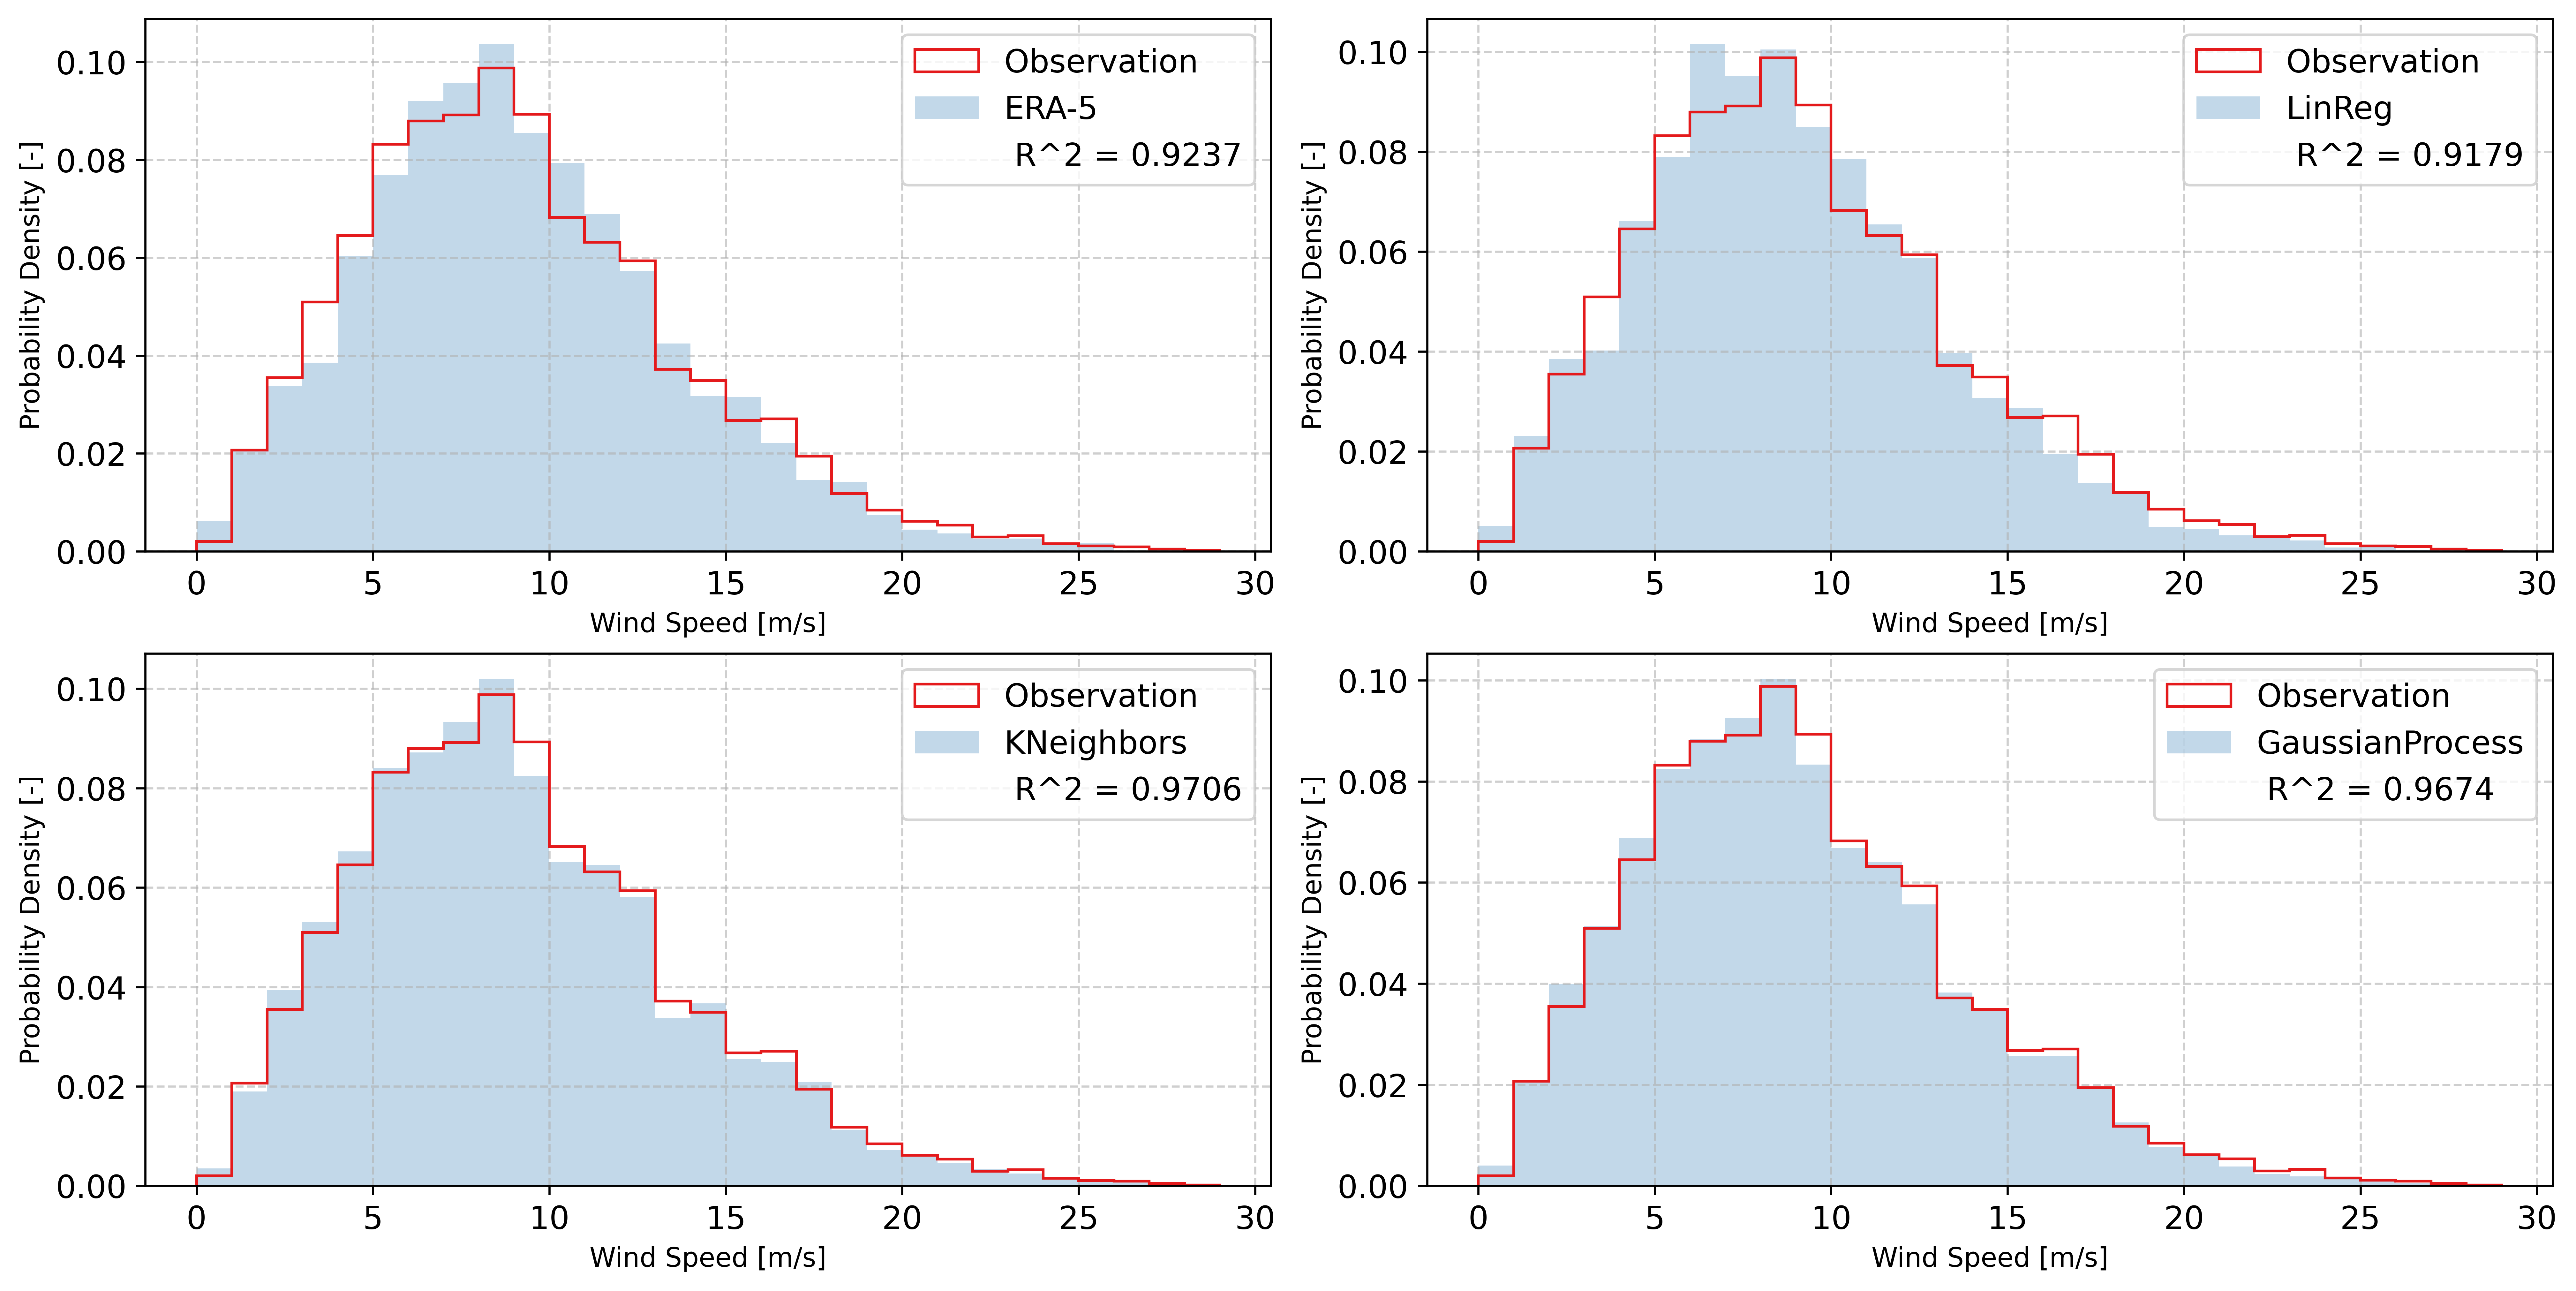

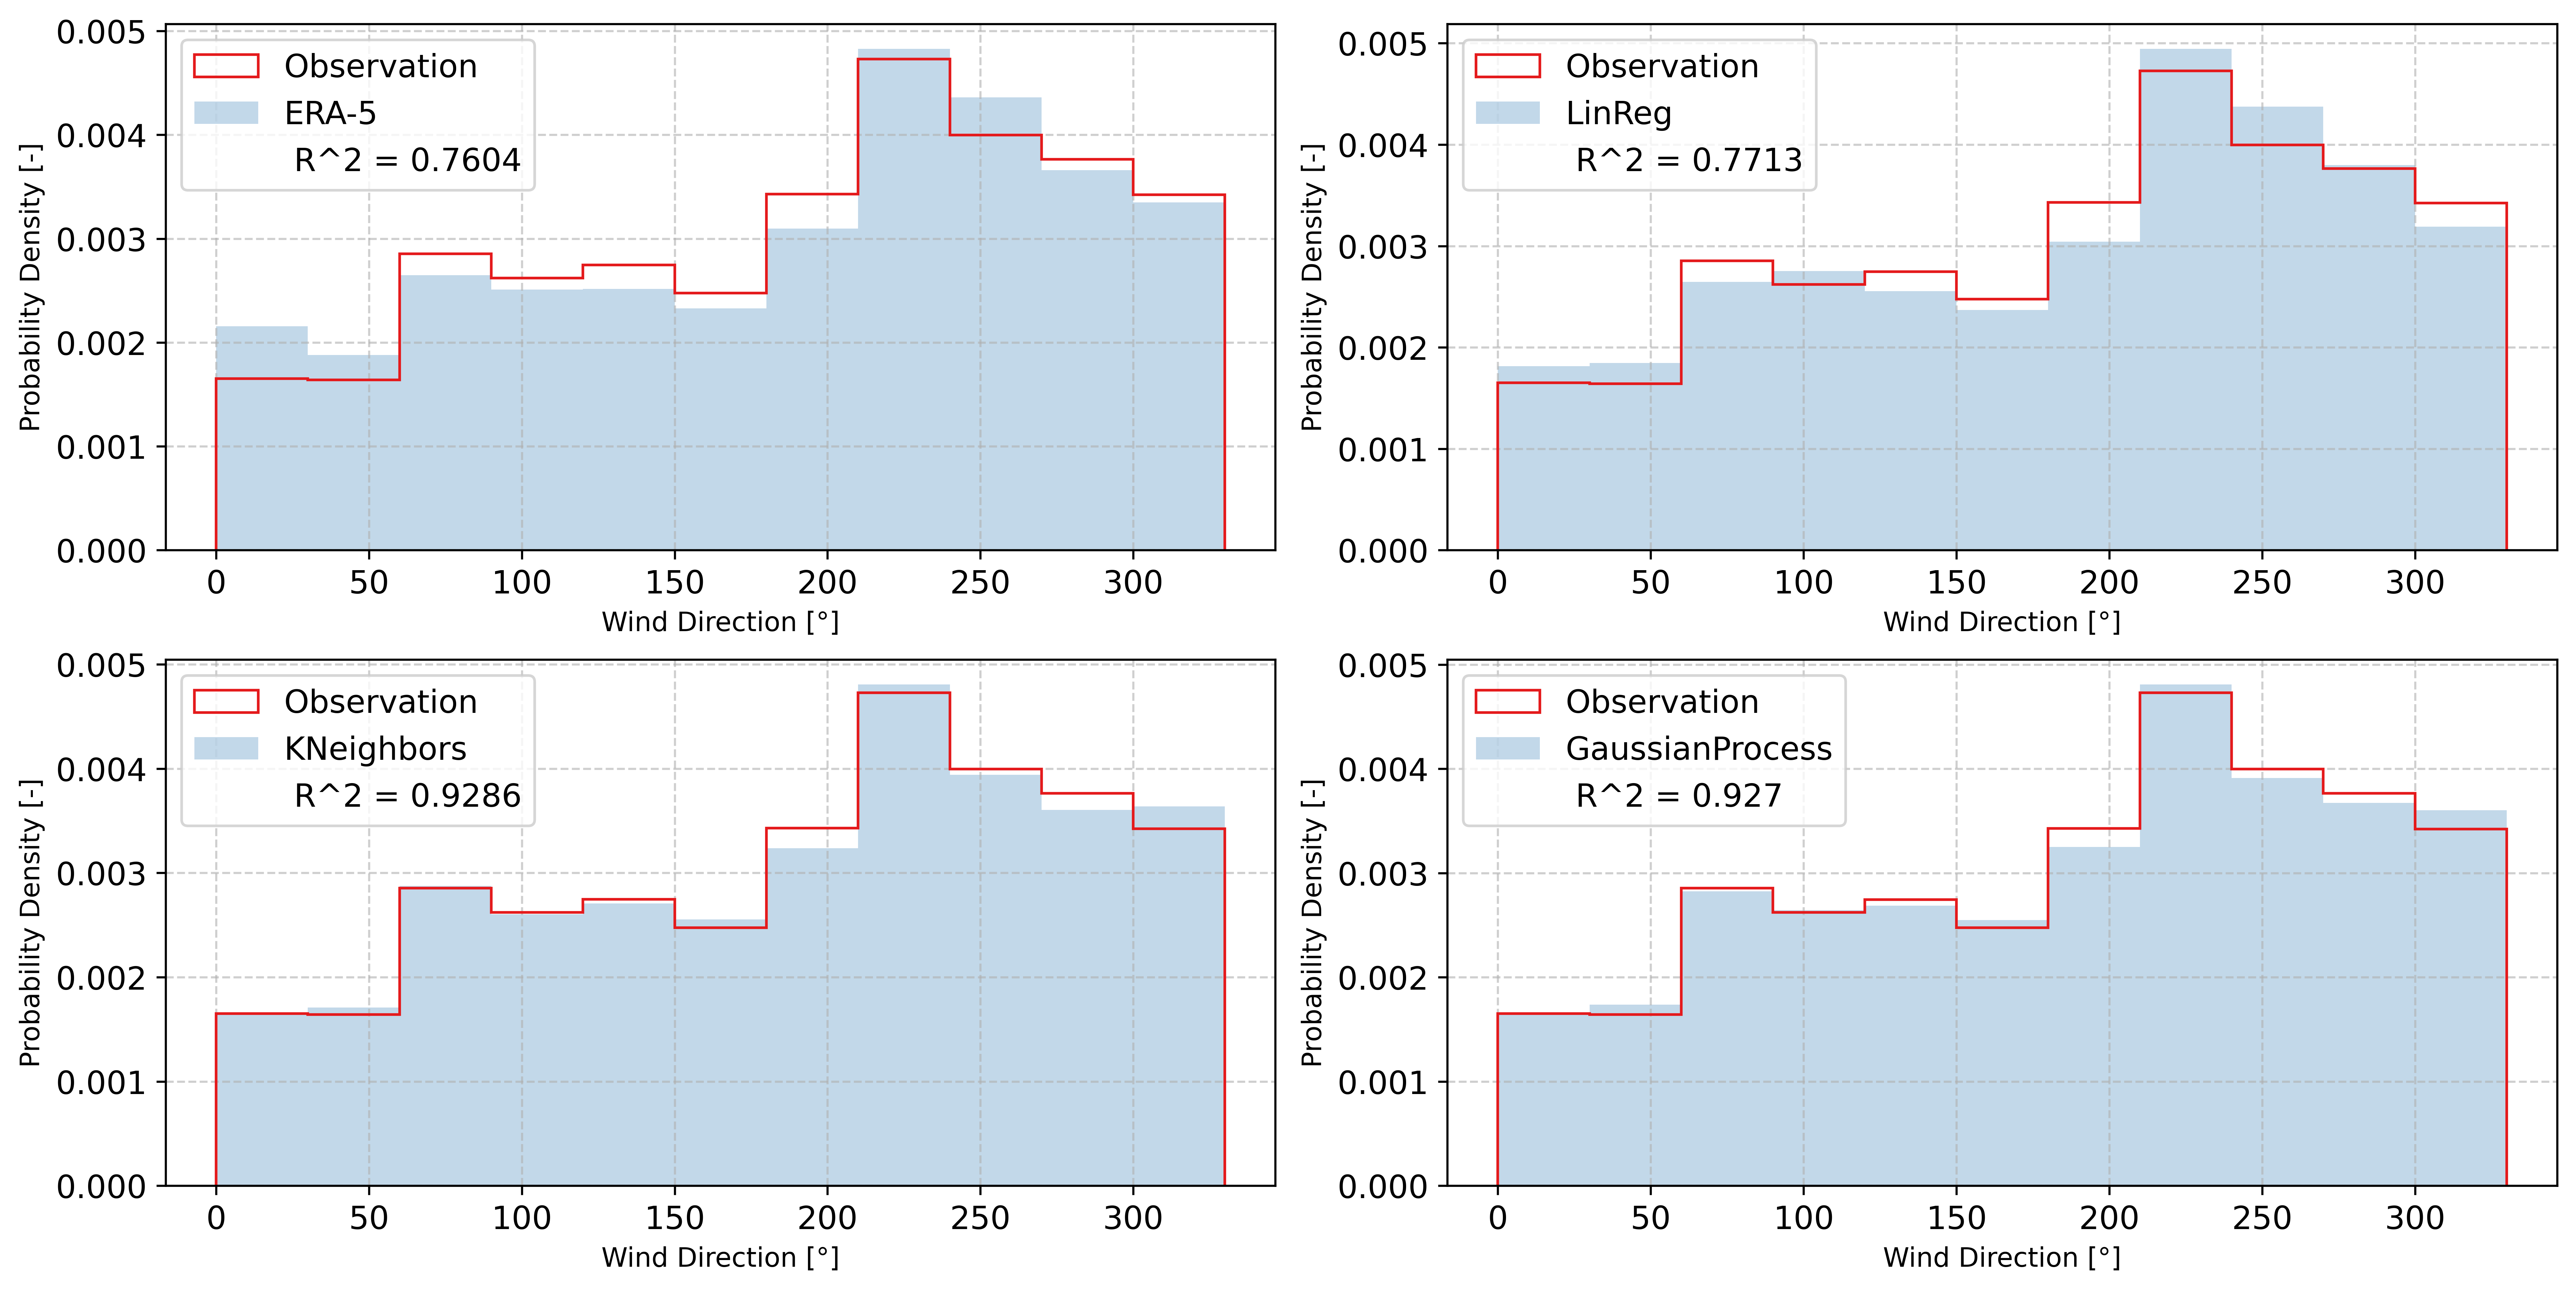

In [145]:
# Unpickle data
meas_idx = np.loadtxt('meas_idx.txt')
wind_data = pd.read_pickle('wind_data')
df_predictions = pd.read_pickle('WS_WD_predictions')

# split the df_predictions in a WS_predictions and WD_predictions List
WS_predictions = [df_predictions.iloc[:,i] for i in range(3)]
WD_predictions = [df_predictions.iloc[:,i + 3] for i in range(3)]

# define the bins for the wind speed histogram
nbins = np.arange(0, 30, 1)

# define figure and axis
fig, ax = plt.subplots(2, 2, layout='compressed')
ax = ax.flatten()

# plot the observation histogram in each axis
[axs.hist(wind_data['WS-99.2'].iloc[meas_idx], nbins, label='Observation', histtype='step', density=True) for axs in ax]

# plot the era-5 data in the first axis and add an empty scatter such that the r^2 score can be written to the legend
ax[0].hist(wind_data['WS100'].iloc[meas_idx], nbins, label='ERA-5', alpha=0.3, density=True)
ax[0].scatter(0, 0, marker='s', alpha=0, label=' R^2 = ' + str(round(r2_score(wind_data['WS-99.2'].iloc[meas_idx], wind_data['WS100'].iloc[meas_idx]), 4)))

# plot the correction histograms for different classifiers in the remaining axis
[ax[i + 1].hist(WS[meas_idx], nbins, label=lbl, alpha=0.3, density=True) 
 for (i, WS, lbl) in 
 zip(range(len(WS_predictions)), WS_predictions, classifier_names)]

# add an empty scatter such that the r^2 score can be written to the legend
[ax[i + 1].scatter(0, 0, marker='s', alpha=0, label=' R^2 = ' + str(round(r2_score(wind_data['WS-99.2'].iloc[meas_idx], WS[meas_idx]), 4))) 
 for i, WS in 
 zip(range(len(WS_predictions)), WS_predictions)]

# make each axis prettier
for axs in ax:
    axs.legend(fontsize= 12)
    axs.grid(True, linestyle="--", alpha=0.6)
    axs.xaxis.set_tick_params(labelsize=12)
    axs.yaxis.set_tick_params(labelsize=12)
    axs.set_xlabel('Wind Speed [m/s]')
    axs.set_ylabel('Probability Density [-]')
plt.show()

# define the bins for the wind speed histogram
nbins = np.arange(0, 360, 30)

# define figure and axis
fig, ax = plt.subplots(2, 2, layout='compressed')
ax = ax.flatten()

# plot the observation histogram in each axis
[axs.hist(wind_data['WD-99.2'].iloc[meas_idx], nbins, label='Observation', histtype='step', density=True) for axs in ax]

# plot the era-5 data in the first axis and add an empty scatter such that the r^2 score can be written to the legend
ax[0].hist(wind_data['WD100'].iloc[meas_idx], nbins, label='ERA-5', alpha=0.3, density=True)
ax[0].scatter(0, 0, marker='s', alpha=0, label=' R^2 = ' + str(round(r2_score(wind_data['WD-99.2'].iloc[meas_idx], wind_data['WD100'].iloc[meas_idx]), 4)))

# plot the correction histograms for different classifiers in the remaining axis
[ax[i + 1].hist(WD[meas_idx], nbins, label=lbl, alpha=0.3, density=True)
 for (i, WD, lbl) in 
 zip(range(len(WD_predictions)), WD_predictions, classifier_names)]

# add an empty scatter such that the r^2 score can be written to the legend
[ax[i + 1].scatter(0, 0, marker='s', alpha=0, label=' R^2 = ' + str(round(r2_score(wind_data['WD-99.2'].iloc[meas_idx], WD[meas_idx]), 4))) 
 for i, WD in 
 zip(range(len(WD_predictions)), WD_predictions)]

# make each axis prettier
for axs in ax:
    axs.legend(fontsize= 12)
    axs.grid(True, linestyle="--", alpha=0.6)
    axs.xaxis.set_tick_params(labelsize=12)
    axs.yaxis.set_tick_params(labelsize=12)
    axs.set_xlabel('Wind Direction [°]')
    axs.set_ylabel('Probability Density [-]')
    
plt.show()

## Measurement Matrix

| Layout  | area_of_interest | aoi + existing turbines |
|---------|------------------|-------------------------|
| Control | ambient = True   | ambient = True          |
| Results | ambient = False  | ambient = False         |

### Load Wind Park Layouts

In [ ]:
# Unpickle wind_data
wind_data = pd.read_pickle('wind_data')

# Define the coordinate path
coords_path = 'turbine-info/coordinates'
# Iterate through all directories in coords_path and store each file path for each directory in a list, which is stored in a list
# e.g. total_layout[0] contains all file paths of all .csv files in the first directory in coords_path, which is 'area_of_interest'
# read all layouts in a list of dataframes such that layout_dfs[0] is the combined layout of all paths in 'area_of_interest' and so on
layout_dfs = [pd.concat([pd.read_csv(file.path) for file in os.scandir(_dir) if file.path.endswith(".csv")]).sort_values(by='y', ascending=False).reset_index(inplace=False)
              for _dir in 
              [_dir.path for _dir in os.scandir(coords_path) if _dir.is_dir()]]

dist_lim = 50000    # distance limit of external turbines from the center of the area of interest

AoI_center = [np.average(layout_dfs[0]['x']), np.average(layout_dfs[0]['y'])]   # Center of the area of interest

ex_layouts = [df.copy() for df in layout_dfs[1:]]  # copy all external layouts

# iterate through all non AoI layouts and drop all columns outside the distance limit
for l in ex_layouts:
    for idx, coordinate in enumerate(l[['x', 'y']].values):
        if np.sqrt((AoI_center[0] - coordinate[0])**2 + (AoI_center[1] - coordinate[1])**2) >= dist_lim:
            
            # drop each turbine from the external layouts, that is too far from the center of the AoI
            l.drop(idx, inplace=True, axis=0)

# Setup of the Algorithms

In [ ]:
# define a start and end date for the time range that is to be used
start_date = "2006-01-01"
end_date = "2006-12-31 23:59"

# define a list of date ranges, one containing the beginnings of the month and one containing the ends
date_chunks = [pd.date_range(start_date, end_date, freq=pd.DateOffset(months=1)), 
               pd.date_range(start_date, end_date, freq='ME') + pd.DateOffset(hours=23, minutes=59)]

# define a list of wake models to be used
wake_models = [["Bastankhah2014_quadratic_ka02"], ["Bastankhah2014_linear_k004", "IECTI2019k_linear_k004"], ["TurbOPark_quadratic_loc_k004", "CrespoHernandez_max_k004"]]

# setup a list of lists, where all the 12 montly algos are stored for each of the wake models
AoI_algo = [[fct.setup_algo(
                            wind_data=wind_data[['WS100_corr', 'WD100_corr', 'TI']].loc[start:end],
                            windfarm_name="N-10.1/N-10.2",
                            wake_models=wake_model,
                            layout_data=layout_dfs[0]) 
             for start, end in zip(date_chunks[0], date_chunks[1])] 
            for wake_model in wake_models
            ]

# setup a list of algos storing all 12 monthly algos for the simulation considering the external layouts
AoI_ex_algo = [fct.setup_algo(
                              wind_data=wind_data[['WS100_corr', 'WD100_corr', 'TI']].loc[start:end],
                              windfarm_name="N-10.1/N-10.2 + External Farms",
                              wake_models=["Bastankhah2014_quadratic_ka02"],
                              layout_data=pd.concat([layout_dfs[0], pd.concat(ex_layouts)])
                              ) for start, end in zip(date_chunks[0], date_chunks[1])
              ]

## Do not run the next two cells, if you ran them once before !!!

In [ ]:
# Simulate the wind farm without external wind turbines for each wake model
AoI_res_list = [[algo.calc_farm() for algo in wake_model] for wake_model in AoI_algo]
# Store the results of the simulation to not have to run this simulation each time
[[res.to_netcdf('./AoI_res/AoI_res_' + str(idx) + '/' + str(i) + '.nc') for i, res in zip(range(len(AoI_res)), AoI_res)] for idx, AoI_res in enumerate(AoI_res_list)]

In [ ]:
# Simulate the wind farm with external wind turbines
AoI_ex_res = [algo.calc_farm() for algo in AoI_ex_algo]
# Store the results of the simulation to not have to run this simulation each time
[res.to_netcdf('./AoI_ex_res/AoI_ex_res' + str(i) + '.nc') for i, res in zip(range(len(AoI_ex_res)), AoI_ex_res)]

## The output from above gets read in here !!!

In [ ]:
# Load the stored .nc files
AoI_res = [[xr.open_dataset(file, engine="netcdf4") for file in os.scandir(_dir) if file.path.endswith(".nc")] for _dir in 
              [_dir.path for _dir in os.scandir('./AoI_res') if _dir.is_dir()]]
AoI_ex_res = [xr.open_dataset(file, engine="netcdf4") for file in os.scandir('./AoI_ex_res') if file.path.endswith(".nc")]

# extract the wind turbine stats and the summary from the results calculated before and store them in a list
AoI_WT_stats, AoI_summary = [[fct.extract_results(res, algo)[0] for res, algo in zip(AoI_res, AoI_algo)], 
                             [fct.extract_results(res, algo)[1] for res, algo in zip(AoI_res, AoI_algo)]]
AoI_ex_WT_stats, AoI_ex_summary = fct.extract_results(AoI_ex_res, AoI_ex_algo)

# Plots of the Wind Farm Results

In [146]:
# Define the out-of-range layouts similar to the external layouts inside the distance limit
oor_layouts = [df.copy() for df in layout_dfs[1:]]

for l in oor_layouts:
    l.reset_index(inplace=True, drop=True)
    for idx, coordinate in enumerate(l[['x', 'y']].values):
        if np.sqrt((AoI_center[0] - coordinate[0])**2 + (AoI_center[1] - coordinate[1])**2) < dist_lim:
            
            # drop each turbine from the external layouts, that is too far from the center of the AoI
            l.drop(idx, inplace=True, axis=0)

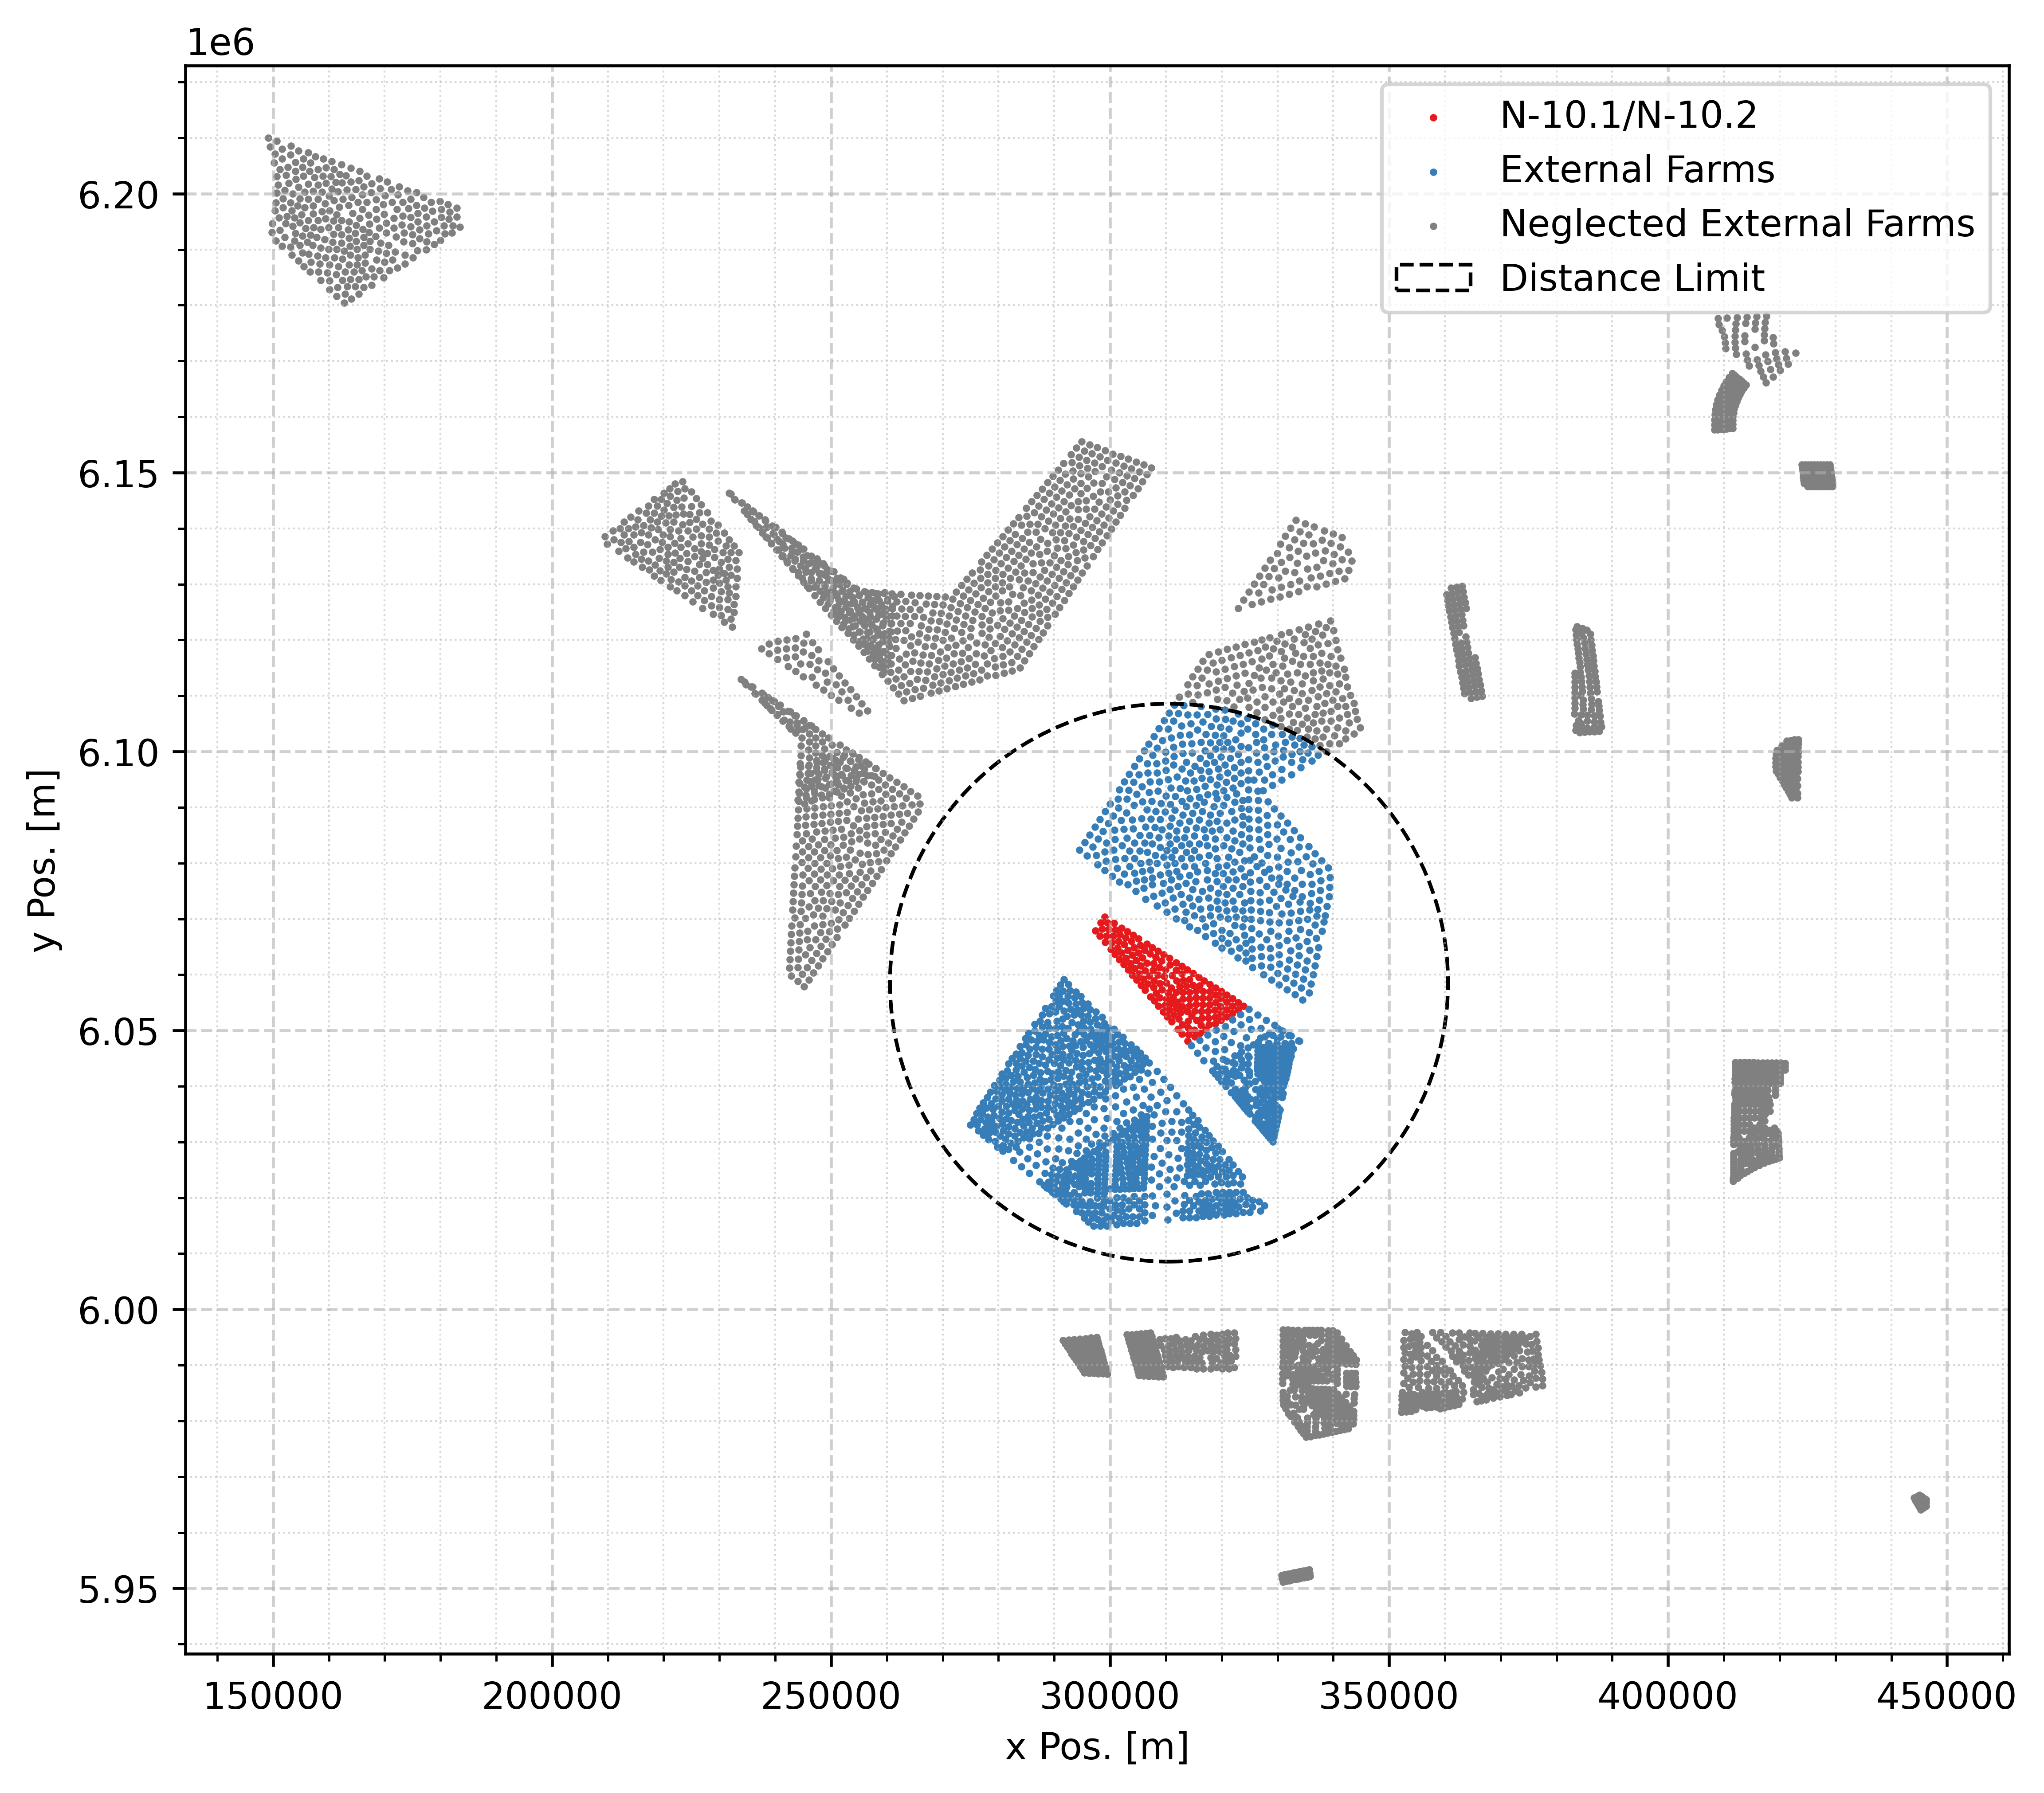

In [ ]:
# define figure and axis
fig, ax = plt.subplots(layout='compressed')

# set the marker size to 1
s = 1

# plot the AoI layout
ax.scatter(layout_dfs[0]['x'], layout_dfs[0]['y'],
           s=s,
           label="N-10.1/N-10.2")

# plot the external layouts wihtin the distance limit
ax.scatter(pd.concat(ex_layouts)['x'], pd.concat(ex_layouts)['y'],
           s=s,
           label='External Farms')

# plot the external layouts outside the distance limit in grey
ax.scatter(pd.concat(oor_layouts)['x'], pd.concat(oor_layouts)['y'],
           c='grey', 
           s=s,
           label='Neglected External Farms')

# plot a circle illustrating the distance limit
dist_lim_circ = plt.Circle(AoI_center, dist_lim, fill=False, ls='--', label='Distance Limit')
ax.add_patch(dist_lim_circ)

ax.minorticks_on()
ax.grid(which='major', linestyle="--", alpha=0.6)
ax.grid(which='minor', linestyle=":", alpha=0.5, linewidth=0.5)
ax.set_xlabel('x Pos. [m]')
ax.set_ylabel('y Pos. [m]')
ax.set_aspect('equal', 'box')
ax.legend()

plt.show()

In [ ]:
# plot the turbine yield per turbine for the simulations neglecting external farm layouts
for WT_stats, wake_model in zip(AoI_WT_stats, wake_models):
    
    # define figure and axis
    fig, ax = plt.subplots(1, 2, layout='compressed')
    ax = ax.flatten()
    
    # define upper and lower limit for the colormap such that both subplots share the same scale
    cbar_min = min(WT_stats['Net Yield [GWh]'].values.min(), WT_stats['Net Ambient Yield [GWh]'].values.min())
    cbar_max = max(WT_stats['Net Yield [GWh]'].values.max(), WT_stats['Net Ambient Yield [GWh]'].values.max())
    norm = Normalize(vmin=cbar_min, vmax=cbar_max)
    
    # plot the layout of the farm without farm wake consideration
    ax[0].scatter(layout_dfs[0]['x'], layout_dfs[0]['y'], 
                  c=WT_stats['Net Ambient Yield [GWh]'].values,
                  marker='2', 
                  norm=norm, 
                  cmap="RdYlBu_r", 
                  s=200)
    ax[0].set_title('No Ambient Wake')
    
    # plot the layout of the farm with farm wake consideration
    sc = ax[1].scatter(layout_dfs[0]['x'], layout_dfs[0]['y'], 
                       c=WT_stats['Net Yield [GWh]'].values,
                       marker='2',
                       norm=norm, 
                       cmap="RdYlBu_r", 
                       s=200)
    ax[1].set_title('Ambient Wake')
    
    # make the axis prettier
    for axs in ax:
        axs.minorticks_on()
        axs.grid(which='major', linestyle="--", alpha=0.6)
        axs.grid(which='minor', linestyle=":", alpha=0.5, linewidth=0.5)
        axs.xaxis.set_tick_params(labelsize=12)
        axs.yaxis.set_tick_params(labelsize=12)
        axs.set_xlabel('x Pos. [m]')
        axs.set_ylabel('y Pos. [m]')
        axs.set_aspect('equal', 'box')
        
    fig.suptitle("Wake Model: '" + ', '.join(wake_model) + "'")
    
    # add the colorbar
    plt.colorbar(sc, label="Annual Net Yield [GWh]", ax=ax.ravel().tolist(), location='bottom', aspect=50)
    plt.show()

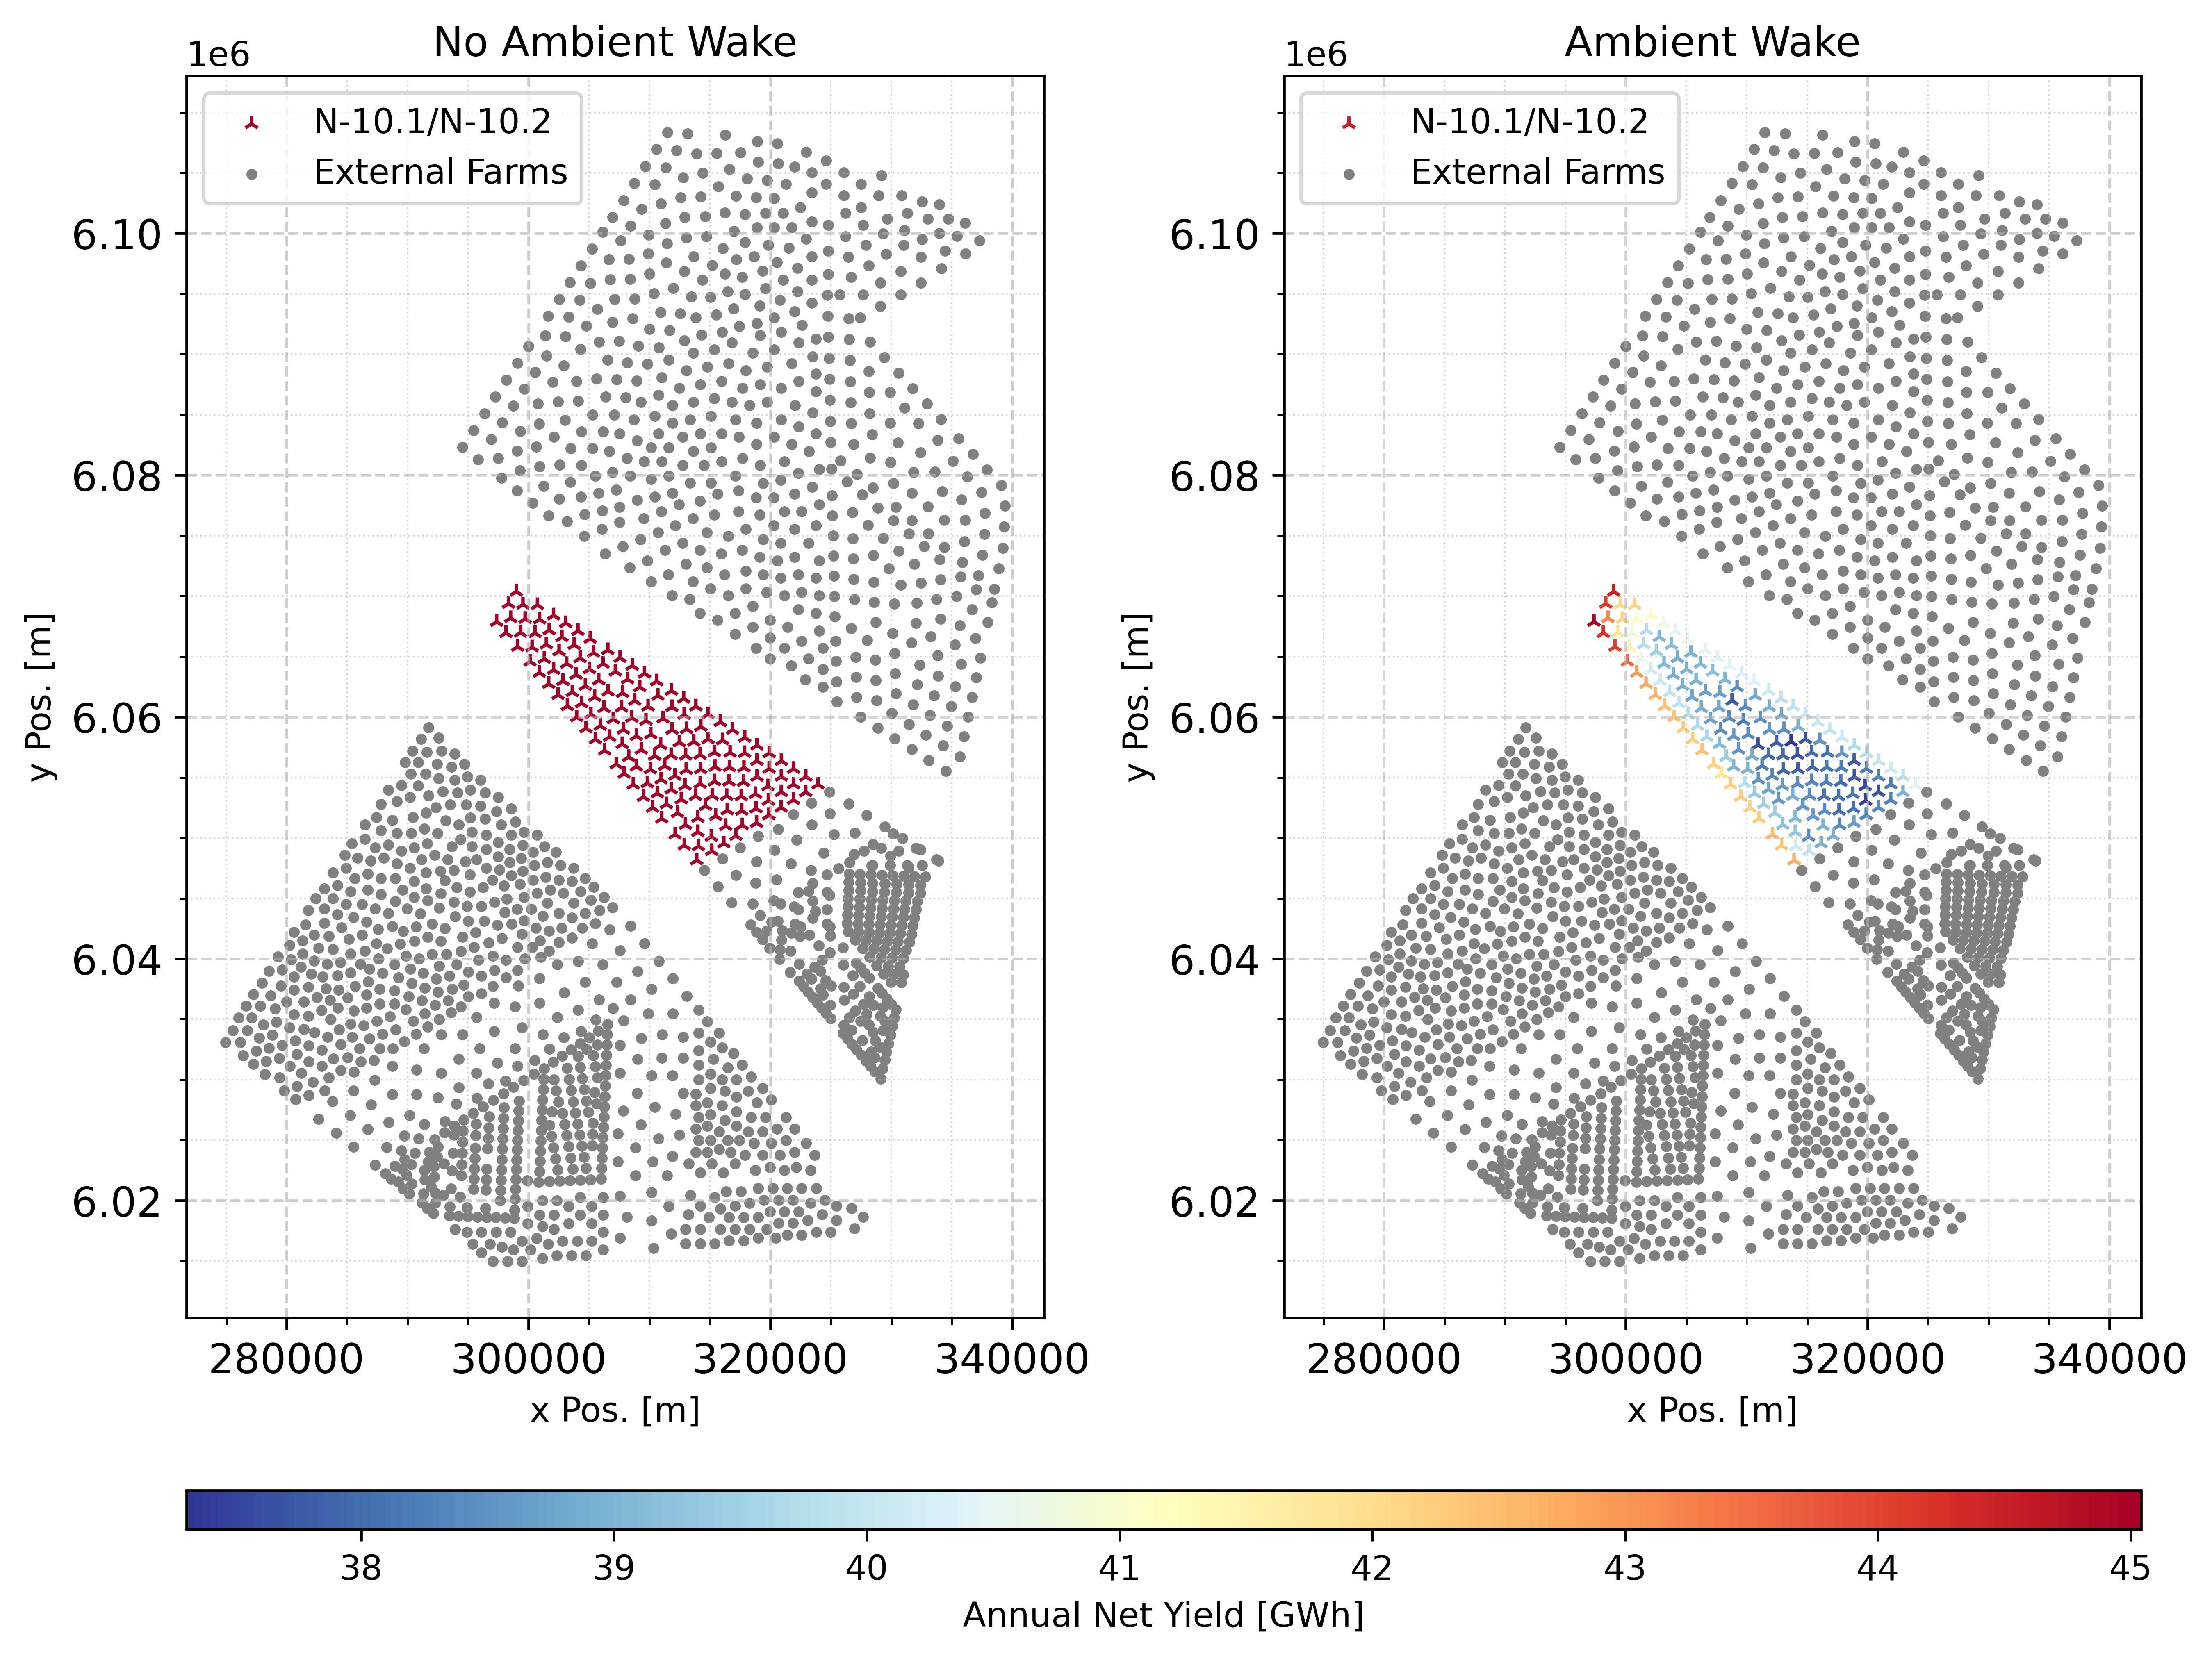

In [ ]:
# define figure and axis
fig, ax = plt.subplots(1, 2, layout='compressed')
ax = ax.flatten()

# define upper and lower limit for the colormap such that both subplots share the same scale
cbar_min = AoI_ex_WT_stats['Net Yield [GWh]'].values[:166].min()
cbar_max = AoI_ex_WT_stats['Net Yield [GWh]'].values[:166].max()
norm = Normalize(vmin=cbar_min, vmax=cbar_max)

# plot the layout of the farm without farm wake consideration
ax[0].scatter(layout_dfs[0]['x'],
              layout_dfs[0]['y'], 
              c=AoI_ex_WT_stats['Net Ambient Yield [GWh]'].values[:166],
              marker='2', 
              norm=norm, 
              cmap="RdYlBu_r", 
              s=20,
              linewidths=1,
              label='N-10.1/N-10.2')

# plot the external farm layouts in grey
ax[0].scatter(pd.concat(ex_layouts)['x'], pd.concat(ex_layouts)['y'], 
              c='grey', 
              s=5,
              label='External Farms')
ax[0].set_title('No Ambient Wake')

# plot the layout of the farm with farm wake consideration
sc = ax[1].scatter(layout_dfs[0]['x'], 
                   layout_dfs[0]['y'], 
                   c=AoI_ex_WT_stats['Net Yield [GWh]'].values[:166],
                   marker='2', 
                   norm=norm, 
                   cmap="RdYlBu_r", 
                   s=20,
                   linewidths=1,
                   label='N-10.1/N-10.2')

# plot the external farm layouts in grey
ax[1].scatter(pd.concat(ex_layouts)['x'], pd.concat(ex_layouts)['y'], 
              c='grey', 
              s=5,
              label='External Farms')
ax[1].set_title('Ambient Wake')

# make the axis prettier
for axs in ax:
    axs.minorticks_on()
    axs.grid(which='major', linestyle="--", alpha=0.6)
    axs.grid(which='minor', linestyle=":", alpha=0.5, linewidth=0.5)
    axs.xaxis.set_tick_params(labelsize=12)
    axs.yaxis.set_tick_params(labelsize=12)
    axs.set_xlabel('x Pos. [m]')
    axs.set_ylabel('y Pos. [m]')
    axs.set_aspect('equal', 'box')
    axs.legend()

# add colorbar    
plt.colorbar(sc, label="Annual Net Yield [GWh]", ax=ax.ravel().tolist(), location='bottom', aspect=50)
plt.show()

In [147]:
AoI_fp2D = foxes.output.FlowPlots2D(AoI_algo[0][0], AoI_res[0][0])